In [1]:
import pandas as pd
from pathlib import Path

df = pd.read_csv(Path.cwd().parent.parent / "archive" / "labeled_data.csv")

df.head()

,amount,use_chip,errors,birth_year,birth_month,gender,yearly_income,total_debt,credit_score,num_credit_cards,...,credit_limit,target,debt_to_income_ratio,years_to_retirement,is_retired,card_age_months,days_until_expiry,hour,dayofweek,is_night
0,-77.00,Swipe Transaction,NaN,1989,7,Female,48277.0,110153.0,740,4,...,55.0,0.0,2.281687,37,False,20,4563,0,4,True
1,14.57,Swipe Transaction,NaN,1971,6,Male,36853.0,112139.0,834,5,...,9100.0,0.0,3.042873,19,False,52,5447,0,4,True
2,80.00,Swipe Transaction,NaN,1970,4,Male,34449.0,36540.0,686,3,...,14802.0,0.0,1.060698,16,False,48,3772,0,4,True
3,46.41,Swipe Transaction,NaN,1968,5,Male,68362.0,96182.0,711,2,...,19113.0,0.0,1.406951,18,False,6,3651,0,4,True
4,4.81,Swipe Transaction,NaN,1972,12,Female,52065.0,98613.0,828,5,...,89.0,0.0,1.894036,18,False,24,1519,0,4,True


In [2]:
X = df.drop(columns=["target"], inplace=False)
y = df["target"].astype(int)

In [3]:
# Check for missing values in target column
y.isna().sum()

np.int64(0)

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y  # stratify to maintain class distribution in train and test sets
    )

In [5]:
# separate categorical and numerical columns
cat_cols = X.select_dtypes(include=['object']).columns
num_cols = X.select_dtypes(exclude=['object']).columns

bin_cols = [col for col in num_cols if X[col].nunique() == 2]
num_cols = [col for col in num_cols if col not in bin_cols]

print(bin_cols)
print(cat_cols)
print(num_cols)

['has_chip', 'is_retired', 'is_night']
Index(['use_chip', 'errors', 'gender', 'card_brand', 'card_type'], dtype='object')
['amount', 'birth_year', 'birth_month', 'yearly_income', 'total_debt', 'credit_score', 'num_credit_cards', 'num_cards_issued', 'credit_limit', 'debt_to_income_ratio', 'years_to_retirement', 'card_age_months', 'days_until_expiry', 'hour', 'dayofweek']


In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('bin', 'passthrough', bin_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

logit_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=2000, class_weight='balanced'))
])

In [8]:
logit_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['amount', 'birth_year',
                                                   'birth_month',
                                                   'yearly_income',
                                                   'total_debt', 'credit_score',
                                                   'num_credit_cards',
                                                   'num_cards_issued',
                                                   'credit_limit',
                                                   'debt_to_income_ratio',
                                                   'years_to_retirement',
                                                   'card_age_months',
                                                   'days_until_expiry', 'hour',
                                                   'dayofweek']),
                                                 ('bin', 'passthrough',
                                                  ['has_chip', 'is_retired',
                                                   'is_night']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['use_chip', 'errors', 'gender', 'card_brand', 'card_type'], dtype='object'))])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=2000))])

In [9]:
y_pred = logit_model.predict(X_test)
y_prob = logit_model.predict_proba(X_test)[:, 1]

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))

[[1526675  253652]
 [    764    1902]]
              precision    recall  f1-score   support

           0       1.00      0.86      0.92   1780327
           1       0.01      0.71      0.01      2666

    accuracy                           0.86   1782993
   macro avg       0.50      0.79      0.47   1782993
weighted avg       1.00      0.86      0.92   1782993

ROC AUC: 0.8539177817309117


Recall: 0.71 - we already catch 71% of the fraud with the baseline model.

In [10]:
threshold = 0.3  # tune
y_pred_adj = (y_prob >= threshold).astype(int)

confusion_matrix(y_test, y_pred_adj)

array([[1028527,  751800],
       [    268,    2398]])

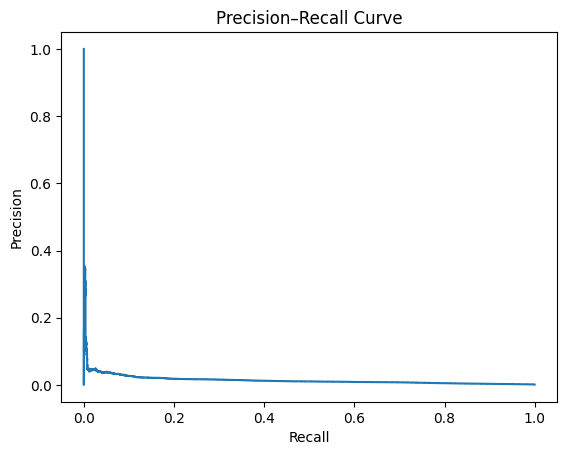

In [11]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

plt.figure()

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")

plt.show()

Model is "confident" on a small subsset but becomes noisy quickly. Again, sign of highly imbalanced classification problem.

In [12]:
from sklearn.metrics import average_precision_score
print(average_precision_score(y_test, y_prob))

0.014391939104763189


LightGBM:

In [13]:
from lightgbm import LGBMClassifier

lgb_model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    class_weight='balanced'
)

for col in cat_cols:
    X_train[col] = X_train[col].astype('category')
    X_test[col]  = X_test[col].astype('category')

# Now LightGBM auto-detects them, no need to pass categorical_feature at all
lgb_model.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 10666, number of negative: 7121304
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.094682 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2224
[LightGBM] [Info] Number of data points in the train set: 7131970, number of used features: 23
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


LGBMClassifier(class_weight='balanced', learning_rate=0.05, n_estimators=300)

In [14]:
y_pred_lgb = lgb_model.predict(X_test)
y_prob_lgb = lgb_model.predict_proba(X_test)[:, 1]

print(confusion_matrix(y_test, y_pred_lgb))
print(classification_report(y_test, y_pred_lgb))
print("ROC AUC:", roc_auc_score(y_test, y_prob_lgb))

[[1596201  184126]
 [    354    2312]]
              precision    recall  f1-score   support

           0       1.00      0.90      0.95   1780327
           1       0.01      0.87      0.02      2666

    accuracy                           0.90   1782993
   macro avg       0.51      0.88      0.48   1782993
weighted avg       1.00      0.90      0.94   1782993

ROC AUC: 0.9473181621412317


1. improvement for the roc auc: model captures more of nonlinear relationships between variables
2. higher fraud detection improved to 0.87
3. false positives (FP) dropped to 184,126

-> great overall improvement

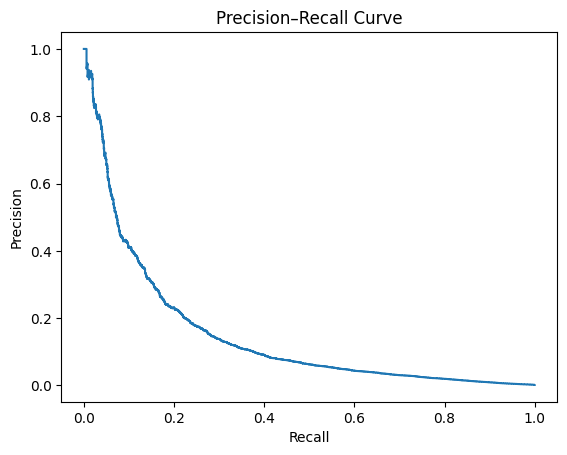

In [15]:
precision, recall, thresholds = precision_recall_curve(y_test, y_prob_lgb)

plt.figure()

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")

plt.show()

In [16]:
aaa = pd.read_csv(Path.cwd().parent.parent / "archive" / "predictions.csv")
aaa.head()

,amount,use_chip,errors,birth_year,birth_month,gender,yearly_income,total_debt,credit_score,num_credit_cards,...,debt_to_income_ratio,years_to_retirement,is_retired,card_age_months,days_until_expiry,hour,dayofweek,is_night,preds,proba
0,200.00,Swipe Transaction,NaN,1967,5,Female,53350.0,128676.0,685,5,...,2.411921,15,False,69,5386,0,4,True,0,0.143486
1,77.00,Swipe Transaction,NaN,1989,7,Female,48277.0,110153.0,740,4,...,2.281687,37,False,20,4563,0,4,True,0,0.063740
2,261.58,Online Transaction,NaN,1973,7,Female,56467.0,66565.0,688,3,...,1.178830,22,False,15,3803,0,4,True,1,0.753226
3,10.74,Swipe Transaction,NaN,1928,9,Female,17150.0,375.0,807,6,...,0.021866,0,True,35,5051,0,4,True,0,0.019400
4,1.09,Swipe Transaction,NaN,1953,3,Male,20577.0,60152.0,825,4,...,2.923264,2,False,70,3833,0,4,True,0,0.015934


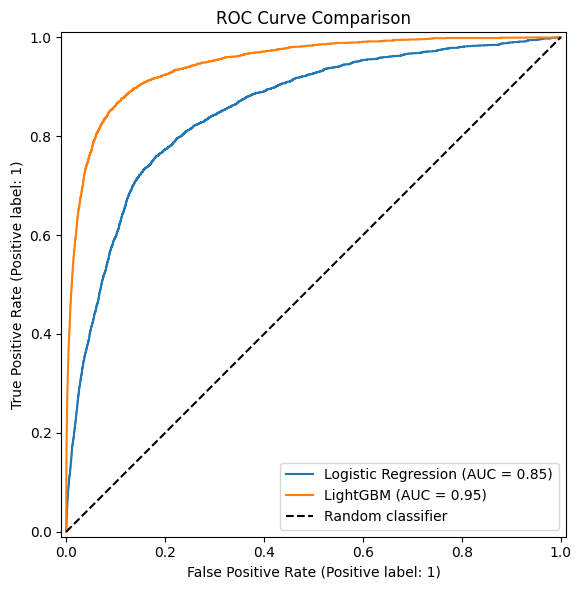

In [17]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))

# Plot both models on the same axes
RocCurveDisplay.from_estimator(logit_model, X_test, y_test, ax=ax, name="Logistic Regression")
RocCurveDisplay.from_estimator(lgb_model, X_test, y_test, ax=ax, name="LightGBM")

ax.plot([0, 1], [0, 1], 'k--', label='Random classifier')
ax.set_title('ROC Curve Comparison')
ax.legend()
plt.tight_layout()
plt.show()

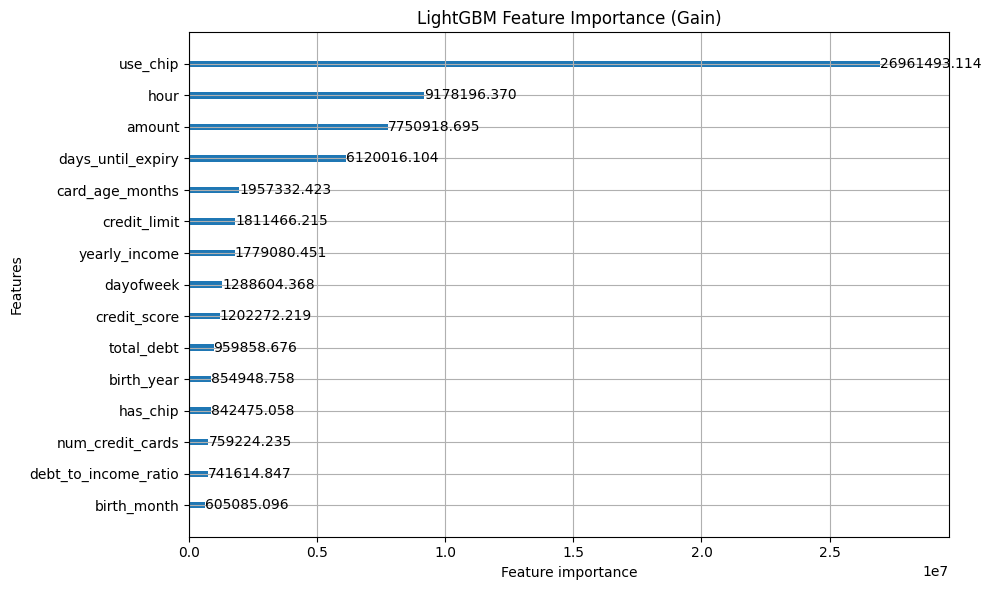

In [18]:
import lightgbm as lgb
import matplotlib.pyplot as plt

lgb.plot_importance(lgb_model, 
                    max_num_features=15,
                    importance_type='gain',
                    figsize=(10, 6),
                    title='LightGBM Feature Importance (Gain)')
plt.tight_layout()
plt.show()

In [19]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import RandomizedSearchCV

lgbm = LGBMClassifier(random_state=42, class_weight='balanced')

param_dist = {
    "n_estimators": [100, 200, 400, 800],
    "learning_rate": [0.01, 0.05, 0.1],
    "num_leaves": [15, 31, 63, 127],
    "max_depth": [-1, 3, 5, 10],
    "min_child_samples": [10, 20, 50, 100],
    "subsample": [0.7, 0.85, 1.0],
    "colsample_bytree": [0.7, 0.85, 1.0]
}

search = RandomizedSearchCV(
    estimator=lgbm,
    param_distributions=param_dist,
    n_iter=20,
    scoring="roc_auc",
    cv=3,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

search.fit(X_train, y_train)

best_model = search.best_estimator_

Fitting 3 folds for each of 20 candidates, totalling 60 fits
[LightGBM] [Info] Number of positive: 7111, number of negative: 4747536
[LightGBM] [Info] Number of positive: 7110, number of negative: 4747536
[LightGBM] [Info] Number of positive: 7111, number of negative: 4747536
[LightGBM] [Info] Number of positive: 7111, number of negative: 4747536
[LightGBM] [Info] Number of positive: 7110, number of negative: 4747536
[LightGBM] [Info] Number of positive: 7111, number of negative: 4747536
[LightGBM] [Info] Number of positive: 7110, number of negative: 4747536
[LightGBM] [Info] Number of positive: 7111, number of negative: 4747536
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.846730 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2224
[LightGBM] [Info] Number of data points in the train set: 4754647, number of used features: 23
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead o

In [20]:
search.best_params_

{'subsample': 1.0,
 'num_leaves': 63,
 'n_estimators': 800,
 'min_child_samples': 20,
 'max_depth': -1,
 'learning_rate': 0.05,
 'colsample_bytree': 0.7}

In [21]:
best_model = search.best_estimator_

In [22]:
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

In [23]:
search.best_score_

np.float64(0.9751861905347545)

In [24]:
y_pred_lgb_best = best_model.predict(X_test)
y_prob_lgb_best = best_model.predict_proba(X_test)[:, 1]

print(confusion_matrix(y_test, y_pred_lgb_best))
print(classification_report(y_test, y_pred_lgb_best))
print("ROC AUC:", roc_auc_score(y_test, y_prob_lgb_best))

[[1718979   61348]
 [    294    2372]]
              precision    recall  f1-score   support

           0       1.00      0.97      0.98   1780327
           1       0.04      0.89      0.07      2666

    accuracy                           0.97   1782993
   macro avg       0.52      0.93      0.53   1782993
weighted avg       1.00      0.97      0.98   1782993

ROC AUC: 0.9787975574457747


Recall only at 0.07, this despite being objectively better, the model captures only 7% of the fraud cases.

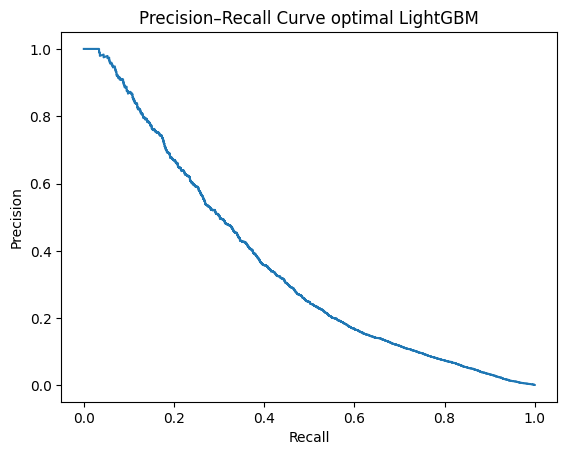

In [25]:
precision, recall, thresholds = precision_recall_curve(y_test, y_prob_lgb_best)

plt.figure()

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve optimal LightGBM")

plt.show()

In [26]:
import joblib
joblib.dump(best_model, Path.cwd().parent / "models" / "lgb_model_v2.pkl")

['/Users/marius/Downloads/M5-Forecasting/models/lgb_model_v2.pkl']

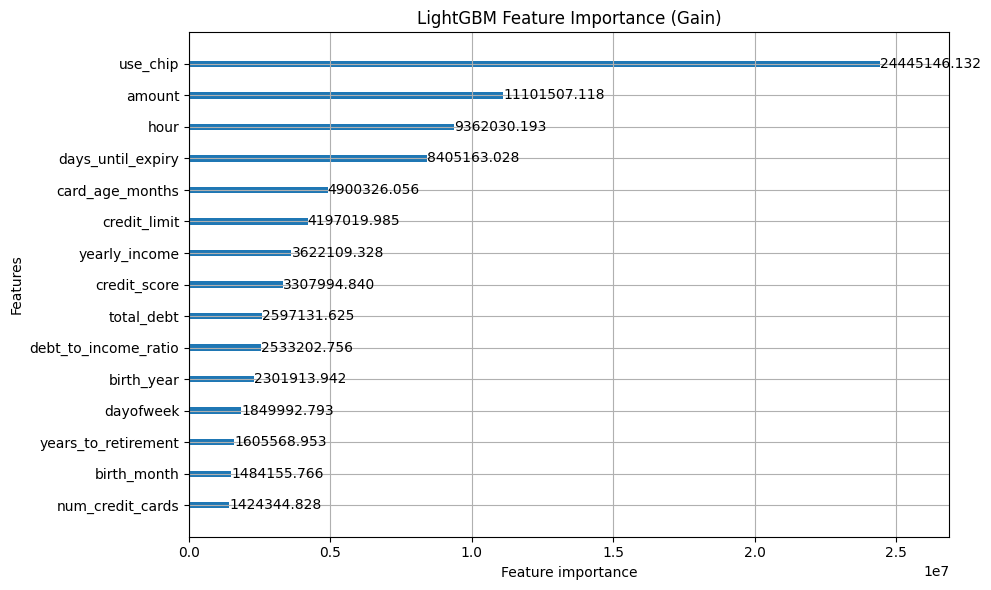

In [27]:
lgb.plot_importance(best_model, 
                    max_num_features=15,
                    importance_type='gain',
                    figsize=(10, 6),
                    title='LightGBM Feature Importance (Gain)')
plt.tight_layout()
plt.show()

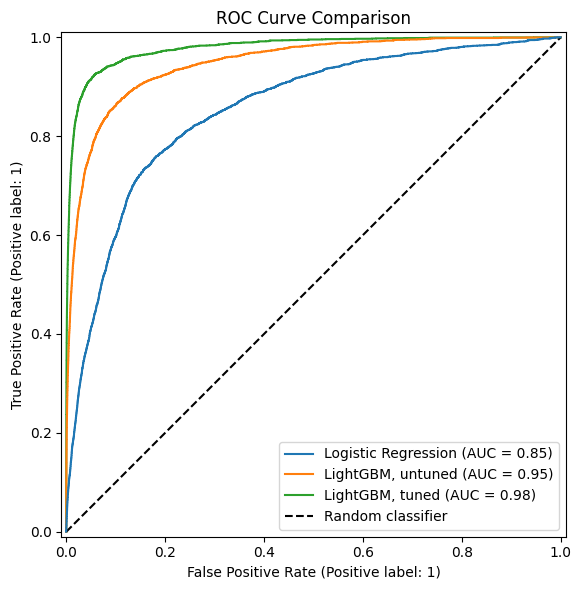

In [28]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))


RocCurveDisplay.from_estimator(logit_model, X_test, y_test, ax=ax, name="Logistic Regression", zorder=3)
RocCurveDisplay.from_estimator(lgb_model, X_test, y_test, ax=ax, name="LightGBM, untuned", zorder=2)
RocCurveDisplay.from_estimator(best_model, X_test, y_test, ax=ax, name="LightGBM, tuned", zorder=1)

ax.plot([0, 1], [0, 1], 'k--', label='Random classifier')
ax.set_title('ROC Curve Comparison')
ax.legend()
plt.tight_layout()
plt.show()

The tuned LightGBM generally has the best fit and a slightly higher AUC than the untuned LightGBM. LightGBM outperforms the LR, potential nonlinearity in the data.

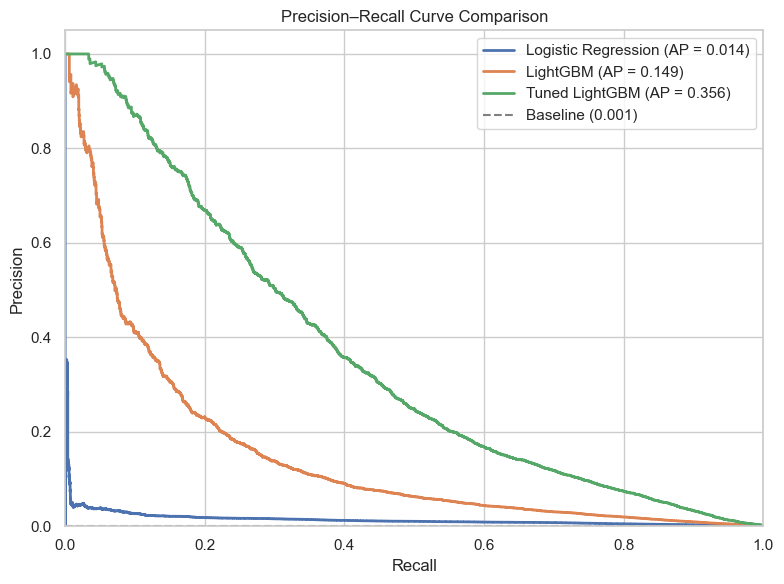

In [30]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.figure(figsize=(8, 6))

models = {
    "Logistic Regression": logit_model,
    "LightGBM": lgb_model,
    "Tuned LightGBM": best_model
}

for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]

    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)

    plt.plot(
        recall,
        precision,
        linewidth=2,
        label=f"{name} (AP = {ap:.3f})"
    )

# set baseline
baseline = y_test.mean()
plt.axhline(
    baseline,
    linestyle="--",
    linewidth=1.5,
    color="gray",
    label=f"Baseline ({baseline:.3f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve Comparison")
plt.xlim(0, 1)
plt.ylim(0, 1.05)
plt.legend(loc="best")
plt.tight_layout()

plt.show()

Ordinate: Precision - accuracy of positive predictions. Here: of all predicted frauds, how many were actually fraudulent?

$Precision = \frac{TP}{TP + FP}$

Abscissa: Recall - completeness. Here: of all frauds in the dataset, how many were found by the model?

$Recall = \frac{TP}{TP + FN}$

